# 03 — End-to-End Training & Inference Demo

This notebook demonstrates a complete pipeline:

1. **Data preparation** — Load a small text dataset using `src/data/dataset.py`.
2. **Configuration** — Build `TransformerConfig` and `TrainerConfig` in Python.
3. **Training** — Train a small decoder-only transformer for a few steps.
4. **Inference** — Generate text from a trained model using `src/inference/engine.py`.

> **Note:** This demo uses a tiny model and synthetic data so it runs
> quickly on CPU. For real experiments, swap in WikiText-2 and a GPU.

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset

from src.models.transformer import Transformer, TransformerConfig
from src.data.tokenizer import Tokenizer
from src.data.dataset import TextDataset
from src.data.collator import DataCollator
from src.training.trainer import Trainer, TrainerConfig
from src.inference.engine import InferenceEngine

sns.set_theme(style="whitegrid")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

c:\Users\aryan\Desktop\Efficient-Transformer-Toolkit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
PyTorch: 2.13.0+cu126


## 1 — Prepare Training Data

We create a small synthetic text corpus. In practice, you would point
`filepaths` at real text files (e.g. WikiText-2 raw wiki.train.tokens).

In [2]:
SYNTHETIC_CORPUS = """
The transformer architecture revolutionized natural language processing by introducing
the self-attention mechanism. Self-attention allows each token in a sequence to attend
to all other tokens, capturing long-range dependencies efficiently.

FlashAttention is an IO-aware algorithm that computes exact attention using
block-wise processing. It reduces memory usage from quadratic to linear in
sequence length while providing significant wall-clock speedups.

Grouped Query Attention shares key and value heads across groups of query heads,
reducing the KV cache size during autoregressive generation. This makes inference
more memory-efficient without significant quality degradation.

ALiBi encodes position information directly into attention scores using linear
biases proportional to token distance. Unlike learned positional embeddings,
ALiBi can extrapolate to sequences longer than those seen during training.

Mixture of Experts activates only a subset of feed-forward parameters for each
token, allowing models to scale to trillions of parameters while keeping
per-token compute manageable.

Knowledge distillation transfers knowledge from a large teacher model to a
smaller student model. The student learns to match the teacher's output
distribution, achieving competitive performance with fewer parameters.

Quantization reduces model weights from 32-bit floating point to lower
precision formats like 8-bit integers or 4-bit normals. This dramatically
reduces memory footprint and can accelerate inference on compatible hardware.

Rotary Position Embeddings encode relative position information by rotating
query and key vectors in 2D subspaces. The rotation angle is proportional to
the absolute position, and the dot product naturally captures relative distances.
"""

# Write to a temporary file
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)
corpus_path = DATA_DIR / "synthetic_corpus.txt"
corpus_path.write_text(SYNTHETIC_CORPUS.strip(), encoding="utf-8")
print(f"Corpus written to {corpus_path} ({corpus_path.stat().st_size} bytes)")
print(f"Word count: {len(SYNTHETIC_CORPUS.split())}")

Corpus written to C:\Users\aryan\Desktop\Efficient-Transformer-Toolkit\data\synthetic_corpus.txt (1809 bytes)
Word count: 235


### Load with Tokenizer and Dataset

In [3]:
# Use GPT-2 tokenizer (small, widely available)
try:
    tokenizer = Tokenizer("gpt2")
    print(f"Tokenizer loaded: vocab_size={tokenizer.vocab_size}")
except Exception as e:
    print(f"Tokenizer load failed ({e}). Using a character-level fallback.")
    # Minimal fallback tokenizer for demo purposes
    class FallbackTokenizer:
        vocab_size = 256
        pad_token_id = 0
        eos_token_id = 1

        def encode(self, text, **kw):
            return [ord(c) % 256 for c in text]

        def decode(self, ids, **kw):
            if isinstance(ids, torch.Tensor):
                ids = ids.tolist()
            if isinstance(ids[0], list):
                return ["".join(chr(i % 256) for i in seq) for seq in ids]
            return "".join(chr(i % 256) for i in ids)

    tokenizer = FallbackTokenizer()

Tokenizer loaded: vocab_size=50257


In [4]:
MAX_SEQ_LEN = 128

dataset = TextDataset(
    tokenizer,
    filepaths=str(corpus_path),
    max_seq_len=MAX_SEQ_LEN,
)

print(f"Dataset: {len(dataset)} windows from {dataset.num_documents} documents")

if len(dataset) > 0:
    sample = dataset[0]
    print(f"Sample keys: {list(sample.keys())}")
    print(f"input_ids length: {len(sample['input_ids'])}")
    decoded = tokenizer.decode(sample["input_ids"][:50])
    print(f"Decoded preview: {decoded[:200]}...")

Dataset: 8 windows from 8 documents
Sample keys: ['input_ids', 'attention_mask', 'labels']
input_ids length: 43
Decoded preview: The transformer architecture revolutionized natural language processing by introducing
the self-attention mechanism. Self-attention allows each token in a sequence to attend
to all other tokens, captu...


In [5]:
# Split into train/val (90/10)
n = len(dataset)
n_val = max(1, n // 10)
n_train = n - n_val

train_dataset = Subset(dataset, list(range(n_train)))
val_dataset = Subset(dataset, list(range(n_train, n)))

collator = DataCollator(tokenizer)

BATCH_SIZE = 4
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator,
)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")

Train batches: 2  Val batches: 1


## 2 — Model & Training Configuration

Since there is no default YAML config, we build everything in Python.
We use a tiny model suitable for CPU training.

In [6]:
model_config = TransformerConfig(
    vocab_size=tokenizer.vocab_size,
    d_model=256,
    n_heads=4,
    n_layers=3,
    d_ff=512,
    max_seq_len=MAX_SEQ_LEN,
    attn_type="flashv2",   # will fall back internally if flash unavailable
    pos_encoding="rope",
    dropout=0.1,
    causal=True,
    use_flash=True,
    tie_embeddings=True,
    ffn_activation="swiglu",
    layer_norm_type="pre",
    use_bias=False,
)

trainer_config = TrainerConfig(
    lr=5e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    num_epochs=100,
    gradient_accumulation_steps=1,
    use_amp=(DEVICE == "cuda"),
    output_dir="outputs/checkpoints_demo",
    save_every=50,
    log_every=5,
    eval_every=1,
    device=DEVICE,
    model_type="decoder_only",
)

print("Model config:")
print(f"  d_model={model_config.d_model}, n_heads={model_config.n_heads}, n_layers={model_config.n_layers}")
print(f"  attn_type={model_config.attn_type}, ffn={model_config.ffn_activation}")
print(f"\nTrainer config:")
print(f"  lr={trainer_config.lr}, epochs={trainer_config.num_epochs}, device={trainer_config.device}")

Model config:
  d_model=256, n_heads=4, n_layers=3
  attn_type=flashv2, ffn=swiglu

Trainer config:
  lr=0.0005, epochs=100, device=cuda


## 3 — Build Model

In [7]:
model = Transformer(
    model_config,
    use_encoder=False,
    use_decoder=True,
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model created: {n_params:,} parameters ({n_params/1e6:.2f}M)")
print(f"Architecture:")
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f"  {name:25s}  {n:>10,} params")

Model created: 15,623,424 parameters (15.62M)
Architecture:
  token_embedding            12,865,792 params
  dropout                             0 params
  decoder                     2,757,632 params
  lm_head                    12,865,792 params


## 4 — Train

In [8]:
trainer = Trainer(
    model=model,
    config=trainer_config,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
)

results = trainer.train()
print(f"\nTraining complete!")
print(f"  Total steps: {results['total_steps']}")
print(f"  Best metric: {results['best_metric']}")
print(f"  Final checkpoint: {results.get('final_checkpoint', 'N/A')}")


Training complete!
  Total steps: 200
  Best metric: 8.680596351623535
  Final checkpoint: outputs\checkpoints_demo\final.pt


### Plot Training Loss

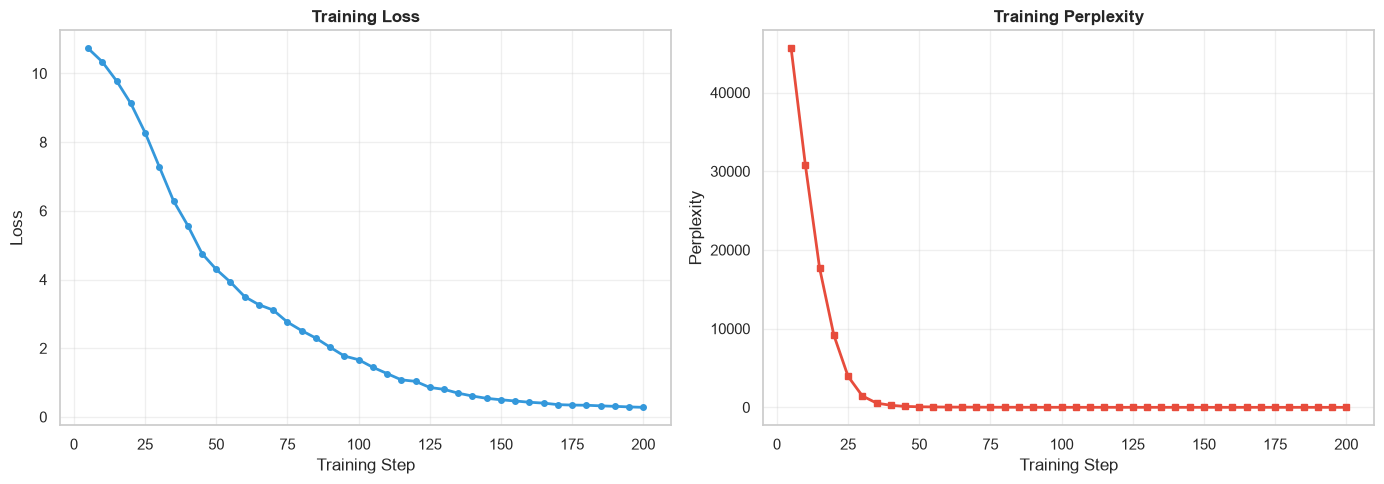

In [9]:
if results["train_history"]:
    steps = [h["step"] for h in results["train_history"]]
    losses = [h["loss"] for h in results["train_history"]]
    ppls = [h.get("ppl", 0) for h in results["train_history"]]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(steps, losses, "o-", color="#3498db", linewidth=2, markersize=4)
    ax1.set_xlabel("Training Step")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training Loss", fontweight="bold")
    ax1.grid(True, alpha=0.3)

    ax2.plot(steps, ppls, "s-", color="#e74c3c", linewidth=2, markersize=4)
    ax2.set_xlabel("Training Step")
    ax2.set_ylabel("Perplexity")
    ax2.set_title("Training Perplexity", fontweight="bold")
    ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()
else:
    print("No training history recorded.")

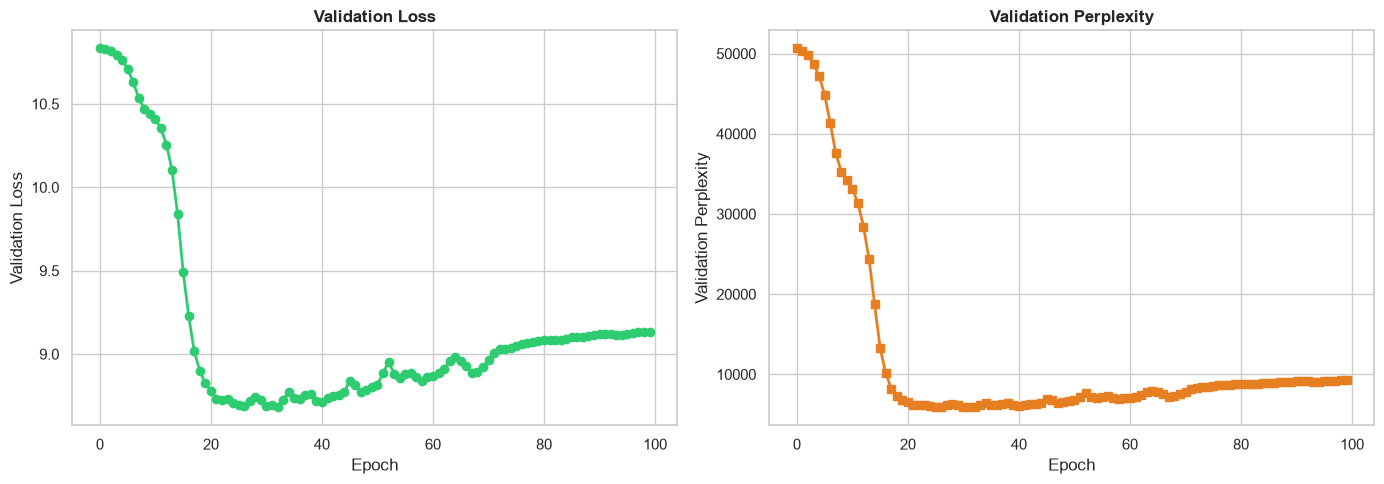

In [10]:
if results["val_history"]:
    val_steps = [h["epoch"] for h in results["val_history"]]
    val_loss = [h["val_loss"] for h in results["val_history"]]
    val_ppl = [h["val_ppl"] for h in results["val_history"]]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(val_steps, val_loss, "o-", color="#2ecc71", linewidth=2, markersize=6)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Validation Loss")
    ax1.set_title("Validation Loss", fontweight="bold")

    ax2.plot(val_steps, val_ppl, "s-", color="#e67e22", linewidth=2, markersize=6)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Validation Perplexity")
    ax2.set_title("Validation Perplexity", fontweight="bold")

    fig.tight_layout()
    plt.show()
else:
    print("No validation history recorded.")

## 5 — Inference with `InferenceEngine`

Load the best checkpoint and generate text from prompts.

In [11]:
# Load best checkpoint if available
best_path = Path(trainer_config.output_dir) / "best.pt"
if not best_path.exists():
    best_path = Path(trainer_config.output_dir) / "final.pt"

if best_path.exists():
    from src.training.checkpoint import load_checkpoint
    meta = load_checkpoint(best_path, model, map_location=DEVICE)
    print(f"Loaded checkpoint from step {meta['global_step']}")
else:
    print("No checkpoint found; using the trained model directly.")

model = model.to(DEVICE).eval()

Loaded checkpoint from step 66


In [12]:
# Create the inference engine
engine = InferenceEngine(
    model=model,
    device=DEVICE,
    use_kv_cache=True,
    pad_token_id=getattr(tokenizer, "pad_token_id", 0),
    eos_token_id=getattr(tokenizer, "eos_token_id", None),
)

print(f"InferenceEngine ready (kv_cache={'enabled' if engine._kv_cache_enabled else 'disabled'})")

InferenceEngine ready (kv_cache=enabled)


In [13]:
# Generate from prompts
prompts = [
    "The transformer",
    "FlashAttention is",
    "Grouped query attention",
]

MAX_GEN = 40

for prompt in prompts:
    input_ids = torch.tensor(
        [tokenizer.encode(prompt, add_special_tokens=False)],
        dtype=torch.long, device=DEVICE,
    )

    output_ids = engine.generate(
        input_ids,
        max_new_tokens=MAX_GEN,
        temperature=0.8,
        top_k=50,
        do_sample=True,
    )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    print(f"\n{'='*60}")
    print(f"Prompt:    {prompt}")
    print(f"Generated: {generated_text}")


Prompt:    The transformer
Generated: The transformer an

 a processing.. teacher during
-. This each
-bit can extrap token-, competitive a. in performance dependencies efficiently. This, each
 with- model.more memory

Prompt:    FlashAttention is
Generated: FlashAttention is mechanism is--sequenceutesutesaware using
.-wise-- a
 length while- models. a.ups. This- token attention using
 usage from wall-
sequence. in

Prompt:    Grouped query attention
Generated: Grouped query attention value heads. The and

distatt the thegressive
red duringore. This. on.'s and the

 quality
reducingmore's
 cache. This footprint-, linear


### Batch Generation

In [14]:
batch_prompts = [
    "Attention mechanisms",
    "The key innovation",
    "Training large models",
    "Memory efficiency",
]

outputs = engine.generate_batch(
    batch_prompts,
    tokenizer=tokenizer if hasattr(tokenizer, "decode") else None,
    max_new_tokens=MAX_GEN,
    temperature=0.8,
    top_k=50,
    do_sample=True,
    return_sequences=False,
)

print("Batch generation results:")
for prompt, output in zip(batch_prompts, outputs):
    print(f"\n  Prompt:    {prompt}")
    print(f"  Generated: {output}")

Batch generation results:

  Prompt:    Attention mechanisms
  Generated: Attention mechanisms distance- a sequence.. fewerutes- This
 efficiently. This to

 can performance linear-
more and compatible hardware. Thisolate to sequences linearrange to parameters. The competitive seen


  Prompt:    The key innovation
  Generated: The key innovation
-.- to
dist hardware. token,

uces eachuces- and can training.-bit and quality.. to's accelerate memory- efficiently token output
red memory memory from

  Prompt:    Training large models
  Generated: Training large models. Self
. with tokens- parameters. performance fewer training. eachBi- of
dist output achieving manageable. or performance on can hardware. inference trainingribution quality. memory onbitucing. performance

  Prompt:    Memory efficiency
  Generated: Memory efficiency a 8. sequence,
att each
-.ention long- models from.- while toention-, capturing. fewer during- memory-. This
ribution
 the memory memoryrange.


## 6 — Inspect Model Parameters

Visualise the parameter distribution across layers.

In [15]:
from src.benchmark.metric import count_parameters, parameter_breakdown

param_info = count_parameters(model)
breakdown = parameter_breakdown(model)

print(f"Total parameters:     {param_info['total']:>12,}")
print(f"Trainable parameters: {param_info['trainable']:>12,}")
print(f"Parameter memory:     {param_info['bytes'] / 1e6:>12.2f} MB")

print("\nBreakdown by module:")
for name, count in sorted(breakdown.items(), key=lambda x: -x[1]):
    bar = "#" * int(count / max(breakdown.values()) * 40)
    print(f"  {name:25s}  {count:>10,}  {bar}")

Total parameters:       15,623,424
Trainable parameters:   15,623,424
Parameter memory:            62.49 MB

Breakdown by module:
  token_embedding            12,865,792  ########################################
  lm_head                    12,865,792  ########################################
  decoder                     2,757,632  ########


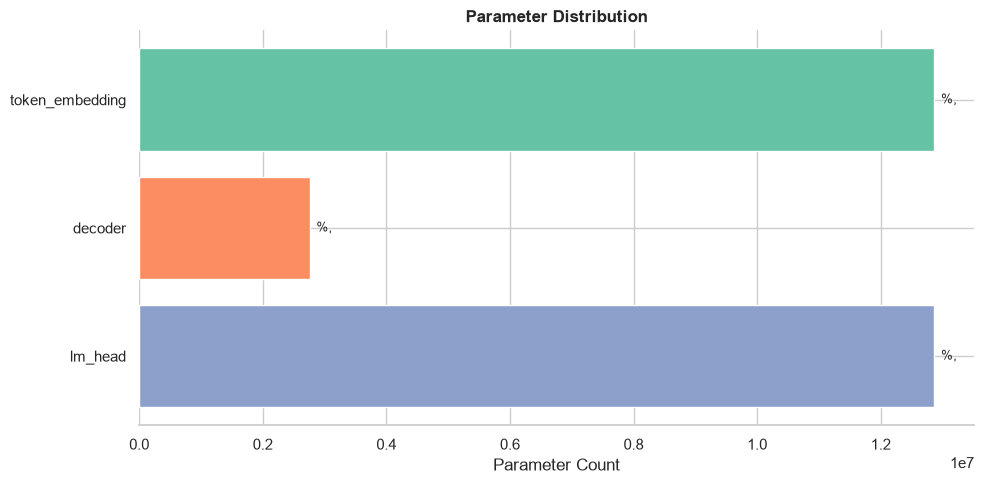

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

names = list(breakdown.keys())
counts = list(breakdown.values())
colors = sns.color_palette("Set2", n_colors=len(names))

bars = ax.barh(names, counts, color=colors, edgecolor="white", linewidth=1)
ax.bar_label(bars, fmt="%,", fontsize=9, padding=5)
ax.set_xlabel("Parameter Count")
ax.set_title("Parameter Distribution", fontweight="bold")
ax.invert_yaxis()
sns.despine(left=True)
fig.tight_layout()
plt.show()

## 7 — Cleanup

In [17]:
model.cpu()
del model, engine, trainer
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Demo complete!")

Demo complete!
